# 01 — Build Spell Topic Model

## What this notebook does

This notebook builds the spell-level topic model used in the project. The goal is to represent each Harry Potter spell as a probabilistic mixture of latent magical themes, rather than assigning each spell to only one fixed category.

The notebook starts from the `Spells.csv` file and treats each spell as a short text document. For each spell, we combine the spell name, effect, and type into one text field. This text is then cleaned, tokenized, filtered for stopwords, and lemmatized so it can be used as input to a Latent Dirichlet Allocation (LDA) model.

The LDA model learns latent topics from the spell descriptions. In this version, the model is partly guided using seed words so that one topic is nudged toward offensive/dark magic and another toward defensive/healing magic. After fitting the model, each spell receives a topic probability distribution. This means that a spell can be partly offensive, partly defensive, or partly neutral, depending on its learned topic probabilities.

The notebook then assigns each spell a dominant topic, gives the main topics interpretable labels, and creates a heatmap showing the topic distribution across all spells.

## What this notebook produces

The main output of this notebook is:

- `spell_topic_matrix.csv`

This file contains one row per spell and includes:

- the spell name
- the incantation
- the dominant LDA topic
- the interpreted topic label
- the full topic probability distribution for each spell

This output is used in the next notebook, where spell incantations are matched to characters in the movie dialogue. In other words, this notebook creates the spell-level representation that later makes it possible to build character-level magical profiles.

### Libaries

In [96]:
import pandas as pd
import re
import nltk
import numpy as np
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.colors as mcolors
import matplotlib.cm as cm


### Get all unique values for spell.csv the "type coulmn"

In [97]:
df = pd.read_csv("Spells.csv")
print(df.head())
print(df.columns.tolist())

   Spell ID       Incantation                        Spell Name  \
0         1             Accio                   Summoning Charm   
1         2         Aguamenti                Water-Making Spell   
2         3  Alarte Ascendare  Launch an object up into the air   
3         4         Alohomora                   Unlocking Charm   
4         5     Arania Exumai            Spider repelling spell   

                  Effect     Light  
0      Summons an object       NaN  
1         Conjures water  Icy blue  
2  Rockets target upward       Red  
3         Unlocks target      Blue  
4         Repels spiders      Blue  
['Spell ID', 'Incantation', 'Spell Name', 'Effect', 'Light']


### Show all unique spell names

In [98]:
# Show all unique spell names
unique_spell_names = df["Spell Name"].dropna().unique()

print(unique_spell_names)
print(f"\nTotal unique spell names: {len(unique_spell_names)}")

['Summoning Charm' 'Water-Making Spell' 'Launch an object up into the air'
 'Unlocking Charm' 'Spider repelling spell' 'Slowing Charm'
 'Killing Curse' 'Exploding Charm' 'Brackium Emendo' 'Cistem Aperio'
 'Locking Spell' 'Blasting Curse' 'Cruciatus Curse' 'Severing Charm'
 'Dissendium' 'Engorgement Charm' 'Episkey' 'Patronus Charm'
 'Disarming Charm' 'Expulso Curse' 'General Counter-Spell'
 'Human Presence Revealing Spell' 'Freezing Charm' 'Impediment Jinx'
 'Imperius Curse' 'Incarcerous Spell' 'Fire-Making Spell' 'Levicorpus'
 'Locomotion Charm' 'Leg-Locker Curse' 'Wand-Lighting Charm'
 'Lumos Maxima' 'Lumos Solem Spell' 'Muffliato Charm'
 'Wand-Extinguishing Charm' 'Memory Charm' 'Oculus Reparo' 'Oppugno Jinx'
 'Peskipiksi Pesternomi' 'Full Body-Bind Curse' 'Piertotum Locomotor'
 'Portus' 'Reverse Spell' 'Shield Charm' 'Protego Maxima'
 'Protego totalum' 'Shrinking Charm' 'Revulsion Jinx' 'Mending Charm'
 'Repello Inimicum' 'Muggle-Repelling Charm' 'Revelio Charm'
 'Tickling Charm' '

In [99]:
print(df.isnull().sum())

Spell ID        0
Incantation     0
Spell Name      0
Effect          0
Light          21
dtype: int64


## Text Preprocessing

Before fitting the LDA model, we transform each spell into a clean text representation. Since LDA works on word counts, each spell is treated as a short document based on the information available in the spell dataset.

We combine the spell name, effect, and type into one text field. Including the spell type is useful because it gives the model additional information about the function of the spell, for example whether it is a charm, curse, jinx, or conjuration.

The text is then preprocessed through the following steps:

1. **Combine text fields**: The spell name, effect, and type are merged into one text string.
2. **Lowercase text**: All words are converted to lowercase so that words such as `"Curse"` and `"curse"` are treated as the same token.
3. **Remove punctuation**: Non-letter characters are removed to simplify the text.
4. **Tokenize**: Each text string is split into individual words.
5. **Remove stopwords**: Common English words such as `"the"`, `"and"`, and `"of"` are removed because they do not carry much topic meaning.
6. **Lemmatize words**: Words are reduced to their base form, so related words are treated more similarly.

The result is a list of cleaned tokens for each spell, which is later used to create the dictionary and bag-of-words corpus for the LDA model.

In [100]:
# Combine text fields
# Include spell type if present so LDA can use explicit class signals where available.
type_col_candidates = [column for column in df.columns if str(column).strip().lower() == "type"]
type_series = df[type_col_candidates[0]].fillna("") if type_col_candidates else ""

df["text"] = (
    df["Spell Name"].fillna("") + " "
    + df["Effect"].fillna("") + " "
    + type_series
)

# Lowercase
df["text"] = df["text"].str.lower()

# Remove punctuation
df["text"] = df["text"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)
import nltk

# Tokenization
df["tokens"] = df["text"].apply(word_tokenize)

# Standard English stopwords
stop_words = set(stopwords.words("english"))

# Harry Potter / dataset-specific stopwords
# Keep generic class words out so topics depend on distinctive terms.
custom_stopwords = {
 
}

# Combine both sets
all_stopwords = stop_words.union(custom_stopwords)

# Remove stopwords
df["tokens"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in all_stopwords]
)

stemmer = PorterStemmer()
lemmer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    #lambda words: [stemmer.stem(w) for w in words]
    lambda words: [lemmer.lemmatize(w) for w in words]
)

# View results
print(df[["Spell Name", "tokens"]].head(20))

                          Spell Name  \
0                    Summoning Charm   
1                 Water-Making Spell   
2   Launch an object up into the air   
3                    Unlocking Charm   
4             Spider repelling spell   
5                      Slowing Charm   
6                      Killing Curse   
7                    Exploding Charm   
8                    Brackium Emendo   
9                      Cistem Aperio   
10                     Locking Spell   
11                    Blasting Curse   
12                   Cruciatus Curse   
13                    Severing Charm   
14                        Dissendium   
15                 Engorgement Charm   
16                           Episkey   
17                    Patronus Charm   
18                   Disarming Charm   
19                     Expulso Curse   

                                             tokens  
0               [summoning, charm, summons, object]  
1             [watermaking, spell, conjures, water]

### Making a dictionary

In [101]:
dictionary = Dictionary(df["tokens"])
dictionary.filter_extremes(
    no_below=1,
    no_above=0.7
)
corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

### Small model

In [102]:
# Guided LDA priors (still LDA): stronger bias for offensive/dark vs defensive/healing terms.
defensive_seed_words = ["heal", "heals", "healing", "episkey", "patronus", "shield", "protect", "protego", "counter", "mend", "defensive"]
offensive_seed_words = ["kill", "killing", "death", "cruciatus", "imperius", "imperio", "avada", "dark", "torture", "unforgivable", "pain", "victim", "curse"]

eta = np.full((3, len(dictionary)), 0.001, dtype=float)
for word in offensive_seed_words:
    word_id = dictionary.token2id.get(word)
    if word_id is not None:
        eta[0, word_id] = 4.0
for word in defensive_seed_words:
    word_id = dictionary.token2id.get(word)
    if word_id is not None:
        eta[1, word_id] = 4.0

alpha = np.array([0.1, 0.1, 0.1])
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=40,
    alpha=alpha,
    eta=eta
)

In [103]:
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.069*"spell" + 0.055*"charm" + 0.052*"curse" + 0.034*"killing" + 0.034*"death" + 0.034*"cruciatus" + 0.034*"pain" + 0.034*"victim" + 0.034*"imperius" + 0.021*"conjures"
Topic 1: 0.048*"charm" + 0.048*"protego" + 0.040*"shield" + 0.040*"mend" + 0.032*"object" + 0.032*"target" + 0.032*"patronus" + 0.032*"episkey" + 0.032*"heals" + 0.027*"curse"
Topic 2: 0.097*"charm" + 0.055*"target" + 0.042*"spell" + 0.042*"jinx" + 0.028*"snake" + 0.028*"object" + 0.028*"memory" + 0.014*"water" + 0.014*"force" + 0.014*"wand"


In [104]:
# Store dominant topic for each spell
dominant_topics = []

# Store full topic probabilities
topic_distributions = []

for bow in corpus:

    # Get topic probabilities
    topic_probs = lda_model.get_document_topics(bow)

    # Save full probability distribution
    topic_distributions.append(topic_probs)

    # Get dominant topic
    dominant_topic = max(topic_probs, key=lambda x: x[1])

    dominant_topics.append(dominant_topic[0])

# Add dominant topic column to dataframe
df["Dominant Topic"] = dominant_topics
print(df[["Spell Name", "Dominant Topic"]].head(20))

                          Spell Name  Dominant Topic
0                    Summoning Charm               0
1                 Water-Making Spell               0
2   Launch an object up into the air               1
3                    Unlocking Charm               2
4             Spider repelling spell               0
5                      Slowing Charm               1
6                      Killing Curse               0
7                    Exploding Charm               1
8                    Brackium Emendo               1
9                      Cistem Aperio               0
10                     Locking Spell               2
11                    Blasting Curse               1
12                   Cruciatus Curse               0
13                    Severing Charm               0
14                        Dissendium               1
15                 Engorgement Charm               1
16                           Episkey               2
17                    Patronus Charm          

## Interpreting and Labelling the LDA Topics

To make the topics interpretable, we inspect the spells that have each topic as their dominant topic. For each topic, we combine the spell name, effect, and type, and then count how often selected marker words appear. The marker words are chosen to represent the two main directions in our good--bad spectrum:

- **Offensive/Dark markers**: words related to harm, pain, death, curses, or dark magic.
- **Defensive/Healing markers**: words related to healing, protection, shielding, or countering magic.

Each topic receives an offensive score and a defensive score based on how often these marker words appear in the spells assigned to that topic. The topic with the strongest offensive signal is labelled as **Offensive/Dark**, while the topic with the strongest defensive signal is labelled as **Defensive/Healing**.

These labels are used to make the LDA output easier to interpret. Importantly, the labels are added after the model has been trained: the model itself only learns latent topics, while we assign human-readable names based on the words and spells associated with each topic.

In [105]:
# LDA-only topic labeling with unique category assignment across all topics.
def topic_profile(topic_id: int) -> dict:
    topic_rows = df[df["Dominant Topic"] == topic_id]
    if topic_rows.empty:
        return {
            "topic_id": topic_id,
            "offensive": 0,
            "defensive": 0,
        }

    type_col_candidates = [column for column in df.columns if str(column).strip().lower() == "type"]
    type_col = type_col_candidates[0] if type_col_candidates else None

    topic_text = (
        topic_rows["Spell Name"].fillna("").str.lower()
        + " "
        + topic_rows["Effect"].fillna("").str.lower()
    )
    if type_col:
        topic_text = topic_text + " " + topic_rows[type_col].fillna("").str.lower()

    offensive_markers = ["imperius", "imperio", "cruciatus", "avada", "killing", "kill", "death", "torture", "pain", "dark", "curse", "Curse"]
    defensive_markers = ["heal", "healing", "episkey", "patronus", "shield", "protect", "protego", "counter", "mend", "disarm"]

    offensive_score = sum(topic_text.str.contains(marker, regex=False).sum() for marker in offensive_markers)
    defensive_score = sum(topic_text.str.contains(marker, regex=False).sum() for marker in defensive_markers)
  

    return {
        "topic_id": topic_id,
        "offensive": int(offensive_score),
        "defensive": int(defensive_score),
    }

profiles = [topic_profile(topic_id) for topic_id in range(lda_model.num_topics)]
profiles_df = pd.DataFrame(profiles)

# Enforce unique top-level categories: exactly one Offensive and one Defensive topic.
offensive_topic = profiles_df.sort_values(["offensive", "defensive"], ascending=[False, True]).iloc[0]["topic_id"]
defensive_topic = profiles_df[~profiles_df["topic_id"].isin([offensive_topic])].sort_values(["defensive", "offensive"], ascending=[False, True]).iloc[0]["topic_id"]

topic_labels = {
    int(offensive_topic): f"LDA Topic {int(offensive_topic)}: Offensive/Dark",
    int(defensive_topic): f"LDA Topic {int(defensive_topic)}: Defensive/Healing",
}

df["Topic Label"] = df["Dominant Topic"].map(topic_labels)

In [106]:
print(df[["Spell Name", "Dominant Topic", "Topic Label"]].head(15))


                          Spell Name  Dominant Topic  \
0                    Summoning Charm               0   
1                 Water-Making Spell               0   
2   Launch an object up into the air               1   
3                    Unlocking Charm               2   
4             Spider repelling spell               0   
5                      Slowing Charm               1   
6                      Killing Curse               0   
7                    Exploding Charm               1   
8                    Brackium Emendo               1   
9                      Cistem Aperio               0   
10                     Locking Spell               2   
11                    Blasting Curse               1   
12                   Cruciatus Curse               0   
13                    Severing Charm               0   
14                        Dissendium               1   

                       Topic Label  
0      LDA Topic 0: Offensive/Dark  
1      LDA Topic 0: Offensive

In [107]:
type_col_candidates = [column for column in df.columns if str(column).strip().lower() == "type"]
view_columns = ["Spell Name", "Effect", "Dominant Topic", "Topic Label"]
if type_col_candidates:
    view_columns.insert(1, type_col_candidates[0])

print(
    df[df["Spell Name"].isin(["Episkey", "Cruciatus Curse", "Killing Curse", "Imperius Curse"])][view_columns]
)

         Spell Name                         Effect  Dominant Topic  \
6     Killing Curse            Instantaneous death               0   
12  Cruciatus Curse              Excruciating pain               0   
16          Episkey           Heals minor injuries               2   
24   Imperius Curse  Total control over the victim               0   

                    Topic Label  
6   LDA Topic 0: Offensive/Dark  
12  LDA Topic 0: Offensive/Dark  
16                          NaN  
24  LDA Topic 0: Offensive/Dark  


### Creating spell topic matrix

In [108]:
topic_matrix = []

for bow in corpus:

    # Get full topic probability distribution
    topic_probs = lda_model.get_document_topics(
        bow,
        minimum_probability=0
    )

    # Convert to dictionary
    row = {
        f"Topic_{topic_id}": prob
        for topic_id, prob in topic_probs
    }

    topic_matrix.append(row)

# Create dataframe
spell_topic_matrix = pd.DataFrame(topic_matrix)

spell_topic_matrix.insert(0, "Spell Name", df["Spell Name"].values)

spell_topic_matrix.insert(1, "Incantation", df["Incantation"].values)

spell_topic_matrix.insert(2, "Dominant Topic", df["Dominant Topic"].values)

spell_topic_matrix.insert(3, "Topic Label", df["Topic Label"].values)

# Preview
print(spell_topic_matrix.head(10))

                         Spell Name       Incantation  Dominant Topic  \
0                   Summoning Charm             Accio               0   
1                Water-Making Spell         Aguamenti               0   
2  Launch an object up into the air  Alarte Ascendare               1   
3                   Unlocking Charm         Alohomora               2   
4            Spider repelling spell     Arania Exumai               0   
5                     Slowing Charm  Arresto Momentum               1   
6                     Killing Curse     Avada Kedavra               0   
7                   Exploding Charm          Bombarda               1   
8                   Brackium Emendo   Brackium Emendo               1   
9                     Cistem Aperio     Cistem Aperio               0   

                      Topic Label   Topic_0   Topic_1   Topic_2  
0     LDA Topic 0: Offensive/Dark  0.953476  0.023261  0.023263  
1     LDA Topic 0: Offensive/Dark  0.953481  0.023257  0.023262 

### Saving to csv

In [109]:
# CSV for easy integration
spell_topic_matrix.to_csv(
    "spell_topic_matrix.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


### Creating barchart for number of spells in each topic

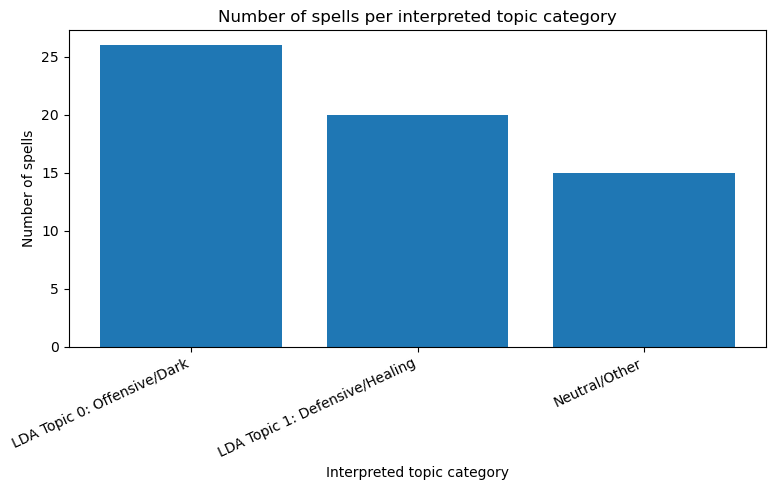

In [110]:
# Count spells per interpreted topic label
topic_counts = df["Topic Label"].fillna("Neutral/Other").value_counts()

plt.figure(figsize=(8, 5))
plt.bar(topic_counts.index, topic_counts.values)

plt.title("Number of spells per interpreted topic category")
plt.xlabel("Interpreted topic category")
plt.ylabel("Number of spells")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

### Creating top 10 good and bad bar chart

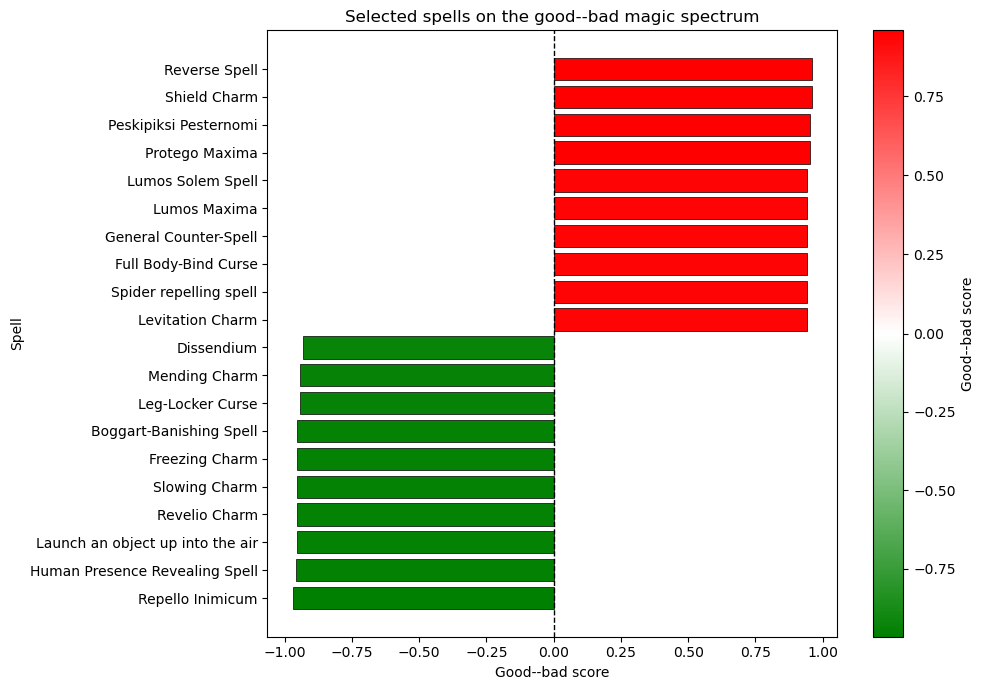

,Spell Name,Incantation,Topic Label,Topic_0,Topic_1,Good_Bad_Score
49,Repello Inimicum,Repello Inimicum,LDA Topic 1: Defensive/Healing,0.010755,0.978492,-0.967738
21,Human Presence Revealing Spell,Homenum Revelio,LDA Topic 1: Defensive/Healing,0.013702,0.972597,-0.958895
2,Launch an object up into the air,Alarte Ascendare,LDA Topic 1: Defensive/Healing,0.015874,0.968250,-0.952376
51,Revelio Charm,Revelio,LDA Topic 1: Defensive/Healing,0.015875,0.968250,-0.952375
5,Slowing Charm,Arresto Momentum,LDA Topic 1: Defensive/Healing,0.015875,0.968249,-0.952374
22,Freezing Charm,Immobulus,LDA Topic 1: Defensive/Healing,0.015875,0.968247,-0.952372
53,Boggart-Banishing Spell,Riddikulus,LDA Topic 1: Defensive/Healing,0.015878,0.968246,-0.952368
29,Leg-Locker Curse,Locomotor Mortis,LDA Topic 1: Defensive/Healing,0.018871,0.962261,-0.943390
48,Mending Charm,Reparo,LDA Topic 1: Defensive/Healing,0.018870,0.962258,-0.943387
14,Dissendium,Dissendium,LDA Topic 1: Defensive/Healing,0.023256,0.953488,-0.930231


In [111]:
# Identify the topic columns
topic_cols = [col for col in spell_topic_matrix.columns if col.startswith("Topic_")]

# Make sure offensive_topic and defensive_topic are integers
offensive_topic = int(offensive_topic)
defensive_topic = int(defensive_topic)

offensive_col = f"Topic_{offensive_topic}"
defensive_col = f"Topic_{defensive_topic}"

# Calculate a good--bad score for each spell
# Positive score  = more dark/offensive
# Negative score  = more good/defensive
# Around 0        = neutral or mixed

spell_topic_matrix["Good_Bad_Score"] = (
    spell_topic_matrix[offensive_col]
    - spell_topic_matrix[defensive_col]
)

# Select the strongest spells on each side of the spectrum

top_bad = spell_topic_matrix.sort_values(
    "Good_Bad_Score",
    ascending=False
).head(10)

top_good = spell_topic_matrix.sort_values(
    "Good_Bad_Score",
    ascending=True
).head(10)

# Combine top good and top bad spells in one figure
spectrum_plot = pd.concat([top_good, top_bad])

# Sort so good/protective spells are at one end and bad/dark spells at the other
spectrum_plot = spectrum_plot.sort_values("Good_Bad_Score")


# Create color gradient
# Green = good/protective, white = neutral, red = bad/dark

cmap = mcolors.LinearSegmentedColormap.from_list(
    "good_bad_cmap",
    ["green", "white", "red"]
)

# Center the color scale at 0
norm = mcolors.TwoSlopeNorm(
    vmin=spectrum_plot["Good_Bad_Score"].min(),
    vcenter=0,
    vmax=spectrum_plot["Good_Bad_Score"].max()
)

colors = cmap(norm(spectrum_plot["Good_Bad_Score"]))

# Plot the spectrum

plt.figure(figsize=(10, 7))

plt.barh(
    spectrum_plot["Spell Name"],
    spectrum_plot["Good_Bad_Score"],
    color=colors,
    edgecolor="black",
    linewidth=0.5
)

# Vertical line at neutral point
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Good--bad score")
plt.ylabel("Spell")
plt.title("Selected spells on the good--bad magic spectrum")

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Good--bad score")

plt.tight_layout()

# Save figure for LaTeX report
plt.savefig("spell_good_bad_spectrum_colored.png", dpi=300, bbox_inches="tight")

plt.show()

# 6. Show the table behind the plot

display(
    spectrum_plot[
        [
            "Spell Name",
            "Incantation",
            "Topic Label",
            offensive_col,
            defensive_col,
            "Good_Bad_Score"
        ]
    ]
)